# SARIMA — Walmart Store Sales Forecasting

Classical Statistical model**

MLflow experiment: `SARIMA_Training`

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mlflow
import pickle

from mlflow_setup import init_mlflow
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import pmdarima as pm
from pmdarima import auto_arima

from features import load_raw_data, merge_all, build_all_features, fill_macro_features, BASE_FEATURES, TARGET
from cv_utils import time_series_cv_splits
from wmae import wmae

DATA_DIR      = "."
RANDOM_SEED   = 42
SEASON_PERIOD = 52  # weekly data, annual seasonality

print(f"statsmodels : {pm.__version__}")
print(f"pmdarima    : {pm.__version__}")

print("imports OK")

statsmodels : 2.1.1
pmdarima    : 2.1.1
imports OK


---
## 1. Data Loading & Stationarity Diagnostics
MLflow run: **SARIMA_Cleaning**

In [ ]:
init_mlflow("SARIMA_Training")

with mlflow.start_run(run_name="SARIMA_Cleaning") as run:
    train_raw, test_raw, features_raw, stores_raw = load_raw_data(DATA_DIR)
    train_merged, test_merged = merge_all(train_raw.copy(), test_raw.copy(), features_raw, stores_raw)
    train_merged = train_merged[train_merged.Weekly_Sales >= 0].reset_index(drop=True)

    # Total weekly sales across all stores/depts
    total_ts = (
        train_merged.groupby('Date')['Weekly_Sales'].sum()
        .sort_index()
        .reset_index()
    )
    total_ts.columns = ['Date', 'Total_Sales']
    total_ts = total_ts.set_index('Date')

    print(f"Total time steps: {len(total_ts)}")
    print(f"Date range: {total_ts.index.min()} → {total_ts.index.max()}")


    adf_result = adfuller(total_ts['Total_Sales'], autolag='AIC')
    print(f"\nADF Statistic : {adf_result[0]:.4f}")
    print(f"p-value       : {adf_result[1]:.4f}")
    print(f"Critical vals : {adf_result[4]}")
    is_stationary_adf = adf_result[1] < 0.05
    print(f"Stationary (ADF): {is_stationary_adf}")

    # -- KPSS Test
    kpss_result = kpss(total_ts['Total_Sales'], regression='c', nlags='auto')
    print(f"\nKPSS Statistic : {kpss_result[0]:.4f}")
    print(f"p-value        : {kpss_result[1]:.4f}")
    is_stationary_kpss = kpss_result[1] > 0.05
    print(f"Stationary (KPSS): {is_stationary_kpss}")

    mlflow.log_metric("adf_pvalue",   adf_result[1])
    mlflow.log_metric("kpss_pvalue",  kpss_result[1])
    mlflow.log_param("n_time_steps",  len(total_ts))
    mlflow.log_param("season_period", SEASON_PERIOD)

    cleaning_run_id = run.info.run_id

print("Cleaning run id:", cleaning_run_id)

Accessing as akave23

Initialized MLflow to track repo "sansi23/Walmart-Recruiting---Store-Sales-Forecasting"

Repository sansi23/Walmart-Recruiting---Store-Sales-Forecasting initialized!

DagsHub connected: https://dagshub.com/sansi23/Walmart-Recruiting---Store-Sales-Forecasting.mlflow
Experiment: SARIMA_Training
Effective tracking URI: https://dagshub.com/sansi23/Walmart-Recruiting---Store-Sales-Forecasting.mlflow
Total time steps: 143
Date range: 2010-02-05 00:00:00 → 2012-10-26 00:00:00

ADF Statistic : -5.9084
p-value       : 0.0000
Critical vals : {'1%': np.float64(-3.47864788917503), '5%': np.float64(-2.882721765644168), '10%': np.float64(-2.578065326612056)}
Stationary (ADF): True

KPSS Statistic : 0.0489
p-value        : 0.1000
Stationary (KPSS): True


C:\Users\admin\AppData\Local\Temp\ipykernel_16332\329858212.py:29: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(total_ts['Total_Sales'], regression='c', nlags='auto')


🏃 View run SARIMA_Cleaning at: https://dagshub.com/sansi23/Walmart-Recruiting---Store-Sales-Forecasting.mlflow/#/experiments/7/runs/47bcde719c354853ac67d5acb1418405
🧪 View experiment at: https://dagshub.com/sansi23/Walmart-Recruiting---Store-Sales-Forecasting.mlflow/#/experiments/7
Cleaning run id: 47bcde719c354853ac67d5acb1418405


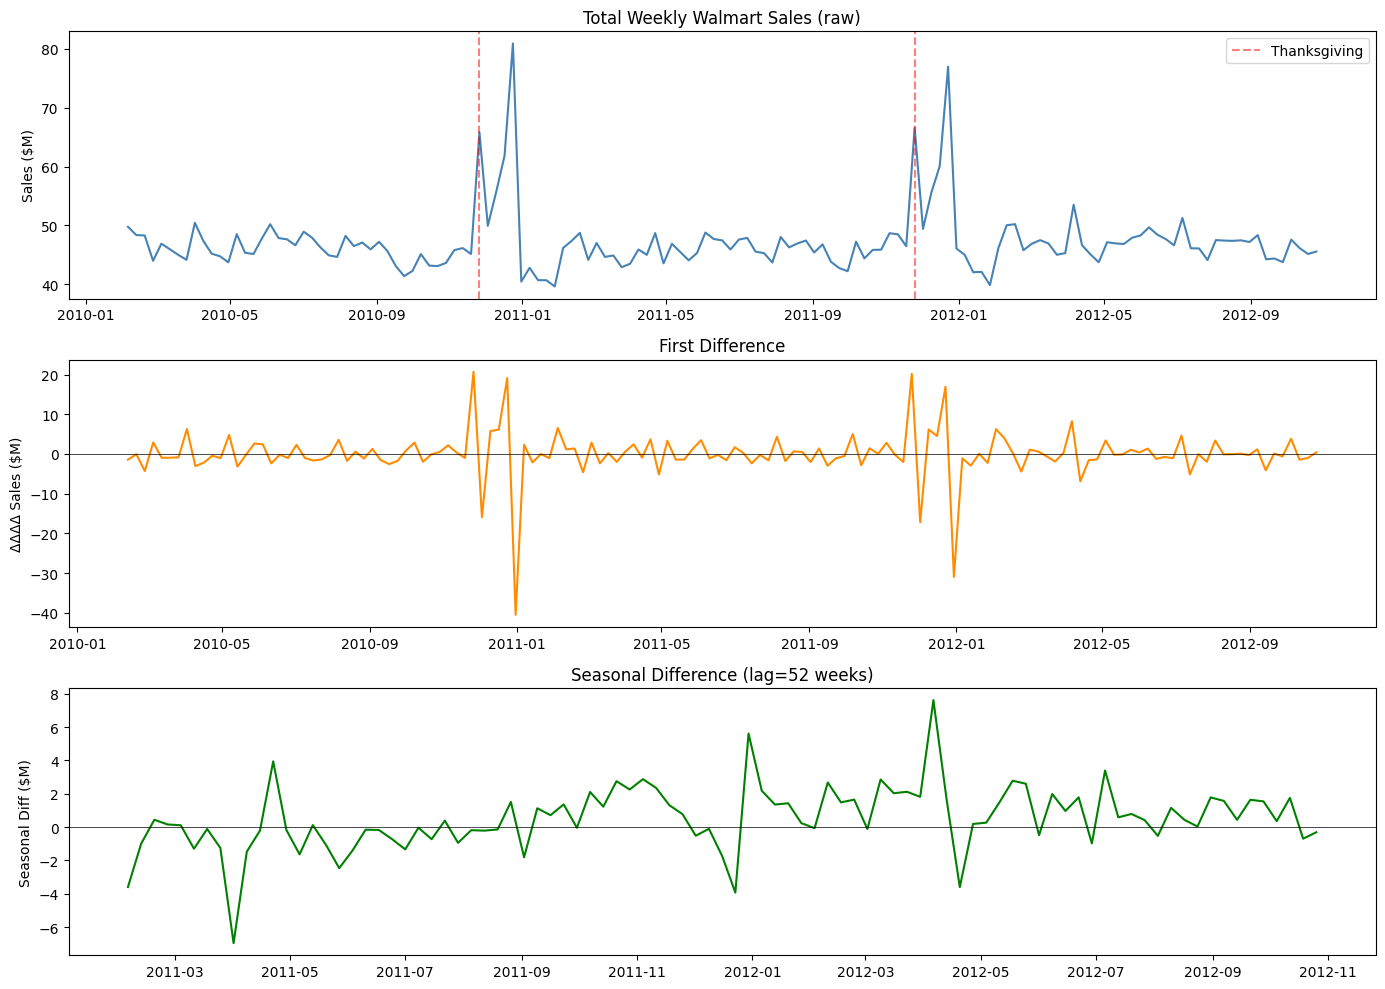

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# Raw series
axes[0].plot(total_ts.index, total_ts['Total_Sales'] / 1e6, color='steelblue')
axes[0].set_title('Total Weekly Walmart Sales (raw)')
axes[0].set_ylabel('Sales ($M)')


diff1 = total_ts['Total_Sales'].diff().dropna()
axes[1].plot(diff1.index, diff1 / 1e6, color='darkorange')
axes[1].set_title('First Difference')
axes[1].set_ylabel('ΔΔΔΔ Sales ($M)')
axes[1].axhline(0, color='k', linewidth=0.5)

# Seasonal difference (lag-52)
diff_s = total_ts['Total_Sales'].diff(52).dropna()
axes[2].plot(diff_s.index, diff_s / 1e6, color='green')
axes[2].set_title('Seasonal Difference (lag=52 weeks)')
axes[2].set_ylabel('Seasonal Diff ($M)')
axes[2].axhline(0, color='k', linewidth=0.5)

plt.tight_layout()
plt.savefig('sarima_stationarity.png', dpi=100)
plt.show()

---
## 2. ACF / PACF Analysis & Parameter Selection

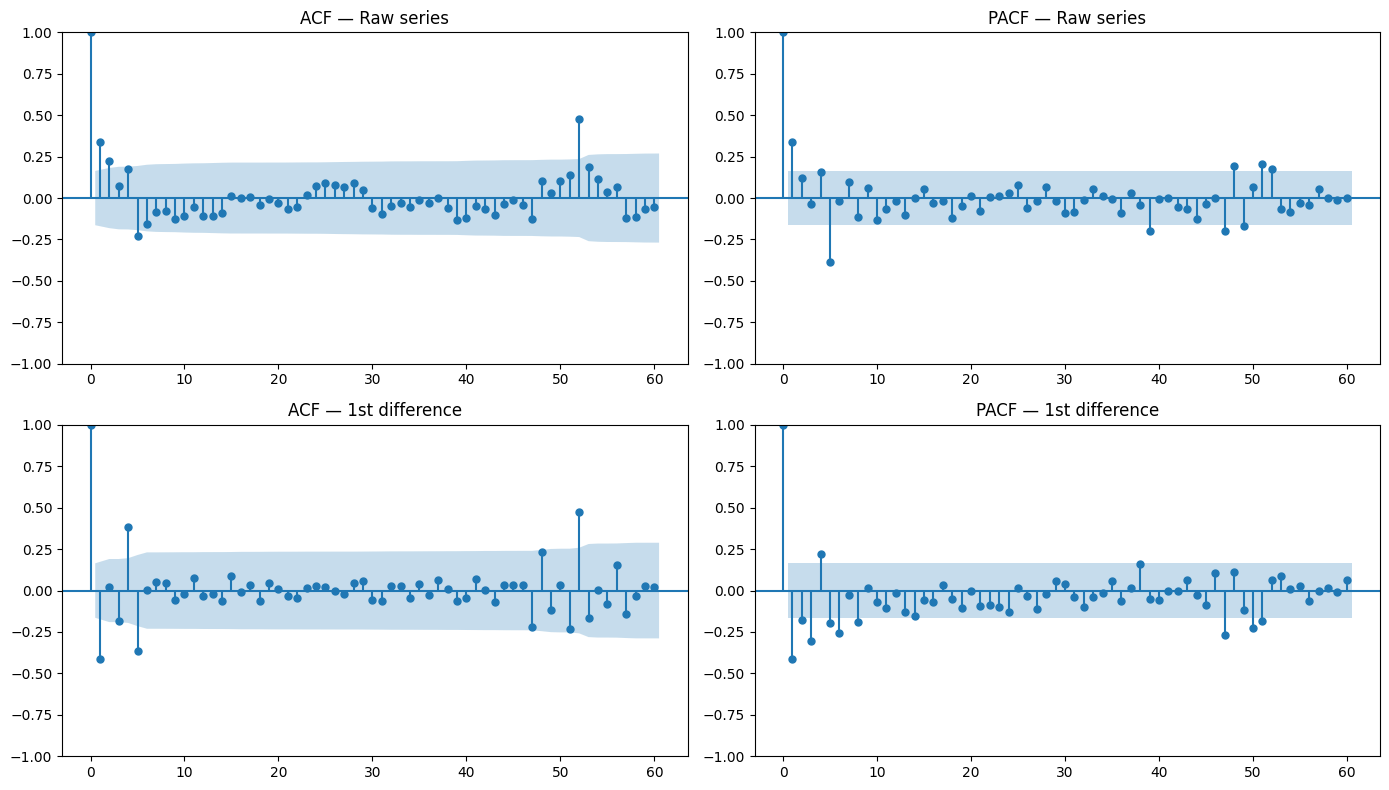

ADF p-value (1st diff): 0.000000  -> stationary: True

Running auto_arima (aggregated series) — this may take a few minutes...
Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,1,0)[52]             : AIC=2907.518, Time=0.22 sec
 ARIMA(1,1,0)(1,1,0)[52]             : AIC=2881.749, Time=2.14 sec
 ARIMA(0,1,1)(0,1,1)[52]             : AIC=2879.433, Time=2.51 sec
 ARIMA(0,1,1)(0,1,0)[52]             : AIC=2891.740, Time=0.30 sec
 ARIMA(0,1,1)(1,1,1)[52]             : AIC=inf, Time=5.93 sec
 ARIMA(0,1,1)(1,1,0)[52]             : AIC=2881.004, Time=2.07 sec
 ARIMA(0,1,0)(0,1,1)[52]             : AIC=2887.341, Time=1.67 sec
 ARIMA(1,1,1)(0,1,1)[52]             : AIC=2881.241, Time=4.01 sec
 ARIMA(0,1,2)(0,1,1)[52]             : AIC=2883.705, Time=2.32 sec
 ARIMA(1,1,0)(0,1,1)[52]             : AIC=2880.331, Time=1.74 sec
 ARIMA(1,1,2)(0,1,1)[52]             : AIC=2885.804, Time=5.37 sec
 ARIMA(0,1,1)(0,1,1)[52] intercept   : AIC=2881.459, Time=1.54 sec

Best model:  ARIMA(0,1,1)(0,1,

In [4]:
with mlflow.start_run(run_name="SARIMA_Feature_Selection") as run:

    # work on first-differenced series for stationarity
    series_diff = total_ts['Total_Sales'].diff().dropna()

    fig, axes = plt.subplots(2, 2, figsize=(14, 8))

    plot_acf( total_ts['Total_Sales'], lags=60, ax=axes[0, 0], title='ACF — Raw series')
    plot_pacf(total_ts['Total_Sales'], lags=60, ax=axes[0, 1], title='PACF — Raw series', method='ywm')
    plot_acf( series_diff,             lags=60, ax=axes[1, 0], title='ACF — 1st difference')
    plot_pacf(series_diff,             lags=60, ax=axes[1, 1], title='PACF — 1st difference', method='ywm')

    plt.tight_layout()
    plt.savefig('sarima_acf_pacf.png', dpi=100)
    plt.show()

    # -- ADF on first-differenced series
    adf_diff = adfuller(series_diff, autolag='AIC')
    print(f"ADF p-value (1st diff): {adf_diff[1]:.6f}  -> stationary: {adf_diff[1] < 0.05}")

    mlflow.log_metric("adf_pvalue_diff1", adf_diff[1])
    mlflow.log_artifact('sarima_acf_pacf.png')

    # -- auto_arima to determine best order (d=1 from ADF analysis)
    print("\nRunning auto_arima (aggregated series) — this may take a few minutes...")
    auto_model = auto_arima(
        total_ts['Total_Sales'],
        start_p=0, start_q=0, max_p=2, max_q=2,
        d=1,
        start_P=0, start_Q=0, max_P=1, max_Q=1,
        D=1, m=52,
        seasonal=True,
        information_criterion='aic',
        stepwise=True,
        suppress_warnings=True,
        trace=True,
    )
    print("\nBest order:", auto_model.order)
    print("Best seasonal order:", auto_model.seasonal_order)
    print(auto_model.summary())

    best_order          = auto_model.order
    best_seasonal_order = auto_model.seasonal_order

    mlflow.log_param("best_p",  best_order[0])
    mlflow.log_param("best_d",  best_order[1])
    mlflow.log_param("best_q",  best_order[2])
    mlflow.log_param("best_P",  best_seasonal_order[0])
    mlflow.log_param("best_D",  best_seasonal_order[1])
    mlflow.log_param("best_Q",  best_seasonal_order[2])
    mlflow.log_param("season",  best_seasonal_order[3])
    mlflow.log_metric("aic",    auto_model.aic())

    feat_run_id = run.info.run_id

print(f"\nauto_arima selected: SARIMA{best_order}x{best_seasonal_order}")

---
## 3. Rolling-Window Cross-Validation on Aggregated Series


In [5]:
def sarima_rolling_cv(series, order, seasonal_order, n_splits=3, val_steps=13):
    """Walk-forward CV for a single time series with SARIMA."""
    n = len(series)
    maes = []

    for fold in range(n_splits):
        val_end   = n - fold * val_steps
        val_start = val_end - val_steps
        if val_start <= max(order[0], seasonal_order[0] * seasonal_order[3]) + 10:
            break

        train_s = series.iloc[:val_start]
        val_s   = series.iloc[val_start:val_end]

        model = SARIMAX(
            train_s, order=order, seasonal_order=seasonal_order,
            enforce_stationarity=False, enforce_invertibility=False
        )
        fit = model.fit(disp=False)
        preds = fit.forecast(steps=val_steps)
        preds = np.clip(preds, 0, None)

        mae = np.mean(np.abs(val_s.values - preds.values))
        maes.append(mae)
        print(f"  Fold {fold+1}: MAE = {mae:,.0f}")

    return np.mean(maes), np.std(maes)


with mlflow.start_run(run_name="SARIMA_CV") as run:
    mlflow.log_param("order",          str(best_order))
    mlflow.log_param("seasonal_order", str(best_seasonal_order))
    mlflow.log_param("n_splits",       3)
    mlflow.log_param("val_steps",      13)
    mlflow.log_param("series_type",    "aggregated_total_sales")

    print(f"Running SARIMA{best_order}x{best_seasonal_order} CV on aggregated series...")
    mean_mae, std_mae = sarima_rolling_cv(
        total_ts['Total_Sales'], best_order, best_seasonal_order,
        n_splits=3, val_steps=13
    )
    print(f"\nCV MAE: {mean_mae:,.0f} ± {std_mae:,.0f}")

    mlflow.log_metric("cv_mae_mean",    mean_mae)
    mlflow.log_metric("cv_mae_std",     std_mae)

    cv_run_id = run.info.run_id

print("CV run id:", cv_run_id)

Running SARIMA(0, 1, 1)x(0, 1, 1, 52) CV on aggregated series...


c:\Users\admin\miniconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
c:\Users\admin\miniconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)


  Fold 1: MAE = 863,860


c:\Users\admin\miniconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
c:\Users\admin\miniconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)


  Fold 2: MAE = 1,115,417


c:\Users\admin\miniconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
c:\Users\admin\miniconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)


  Fold 3: MAE = 1,758,439

CV MAE: 1,245,906 ± 376,686
🏃 View run SARIMA_CV at: https://dagshub.com/sansi23/Walmart-Recruiting---Store-Sales-Forecasting.mlflow/#/experiments/7/runs/8f6a281c96754059ad99ed437af42c46
🧪 View experiment at: https://dagshub.com/sansi23/Walmart-Recruiting---Store-Sales-Forecasting.mlflow/#/experiments/7
CV run id: 8f6a281c96754059ad99ed437af42c46


---
## 4. Hyperparameter Comparison — a few candidate orders, not a big grid


In [ ]:

N_TUNING_SERIES = 5

# identify top store-dept pairs by total sales
top_pairs = (
    train_merged.groupby(['Store', 'Dept'])['Weekly_Sales']
    .sum()
    .sort_values(ascending=False)
    .head(N_TUNING_SERIES)
    .reset_index()
)
print(f"Top {N_TUNING_SERIES} store-dept pairs:")
print(top_pairs.to_string())

# Cut-off: last 13 weeks as validation
all_dates = sorted(train_merged['Date'].unique())
cutoff    = all_dates[-13]


sarima_candidates = [
    {"name": "AutoARIMA_Selected", "order": best_order,   "seasonal_order": best_seasonal_order},
    {"name": "Simple_111",         "order": (1, 1, 1),    "seasonal_order": (1, 1, 1, SEASON_PERIOD)},
    {"name": "Seasonal_212",       "order": (2, 1, 2),    "seasonal_order": (1, 1, 1, SEASON_PERIOD)},
]

tuning_results = []

for cand in sarima_candidates:
    name = cand["name"]
    with mlflow.start_run(run_name=f"SARIMA_Tuning_{name}") as run:
        mlflow.log_param("order",          str(cand["order"]))
        mlflow.log_param("seasonal_order", str(cand["seasonal_order"]))
        mlflow.log_param("n_series",       N_TUNING_SERIES)
        mlflow.log_param("selection",      f"top_{N_TUNING_SERIES}_by_total_sales")
        mlflow.log_param("val_weeks",      13)

        preds_all, actuals_all, holiday_all = [], [], []
        for _, row in top_pairs.iterrows():
            store, dept = int(row.Store), int(row.Dept)
            series_data = (
                train_merged[(train_merged.Store == store) & (train_merged.Dept == dept)]
                .sort_values('Date')
                .set_index('Date')['Weekly_Sales']
            )
            if len(series_data) < 52 + 13 + 10:
                continue

            train_s = series_data[series_data.index < cutoff]
            val_s   = series_data[series_data.index >= cutoff]

            try:
                fit = SARIMAX(
                    train_s, order=cand["order"], seasonal_order=cand["seasonal_order"],
                    enforce_stationarity=False, enforce_invertibility=False,
                ).fit(disp=False)
                preds_s = np.clip(fit.forecast(steps=len(val_s)).values, 0, None)
            except Exception as e:
                print(f"    S{store}/D{dept} failed for {name}: {e}")
                continue

            hol_val = train_merged[
                (train_merged.Store == store) & (train_merged.Dept == dept) &
                (train_merged.Date >= cutoff)
            ]['IsHoliday'].values

            preds_all.append(preds_s)
            actuals_all.append(val_s.values)
            holiday_all.append(hol_val)

        score = wmae(np.concatenate(actuals_all), np.concatenate(preds_all), np.concatenate(holiday_all))
        mlflow.log_metric("val_wmae", score)
        print(f"  {name:22s} order={cand['order']} s={cand['seasonal_order']}  "
              f"pooled WMAE={score:,.2f}  (n_series={len(preds_all)})")

        tuning_run_id = run.info.run_id

    tuning_results.append({**cand, "wmae": score})

tuning_results.sort(key=lambda r: r["wmae"])
print("\nHyperparameter comparison results (best first):")
for r in tuning_results:
    print(f"  {r['name']:22s}  WMAE = {r['wmae']:,.2f}")

winner = tuning_results[0]
best_order, best_seasonal_order = winner["order"], winner["seasonal_order"]
mean_wmae = winner["wmae"]
print(f"\nWinning config: {winner['name']}  order={best_order}  seasonal_order={best_seasonal_order}")
print("(best_order/best_seasonal_order now point at the WINNER, used for the final ensemble in section 6)")

Top 5 store-dept pairs:
   Store  Dept  Weekly_Sales
0     14    92   26101497.71
1      2    92   23572153.03
2     20    92   23542625.04
3     13    92   23170876.20
4      4    92   22789210.43


c:\Users\admin\miniconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
c:\Users\admin\miniconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
c:\Users\admin\miniconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
c:\Users\admin\miniconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
c:\Users\admin\miniconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-

  AutoARIMA_Selected     order=(0, 1, 1) s=(0, 1, 1, 52)  pooled WMAE=8,702.34  (n_series=5)
🏃 View run SARIMA_Tuning_AutoARIMA_Selected at: https://dagshub.com/sansi23/Walmart-Recruiting---Store-Sales-Forecasting.mlflow/#/experiments/7/runs/06391f6977e54f81a7232051450346bb
🧪 View experiment at: https://dagshub.com/sansi23/Walmart-Recruiting---Store-Sales-Forecasting.mlflow/#/experiments/7


c:\Users\admin\miniconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
c:\Users\admin\miniconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
c:\Users\admin\miniconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
c:\Users\admin\miniconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
c:\Users\admin\miniconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-

  Simple_111             order=(1, 1, 1) s=(1, 1, 1, 52)  pooled WMAE=8,000.88  (n_series=5)
🏃 View run SARIMA_Tuning_Simple_111 at: https://dagshub.com/sansi23/Walmart-Recruiting---Store-Sales-Forecasting.mlflow/#/experiments/7/runs/44bb96aed8114a619884408738303917
🧪 View experiment at: https://dagshub.com/sansi23/Walmart-Recruiting---Store-Sales-Forecasting.mlflow/#/experiments/7


c:\Users\admin\miniconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
c:\Users\admin\miniconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
c:\Users\admin\miniconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
c:\Users\admin\miniconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
c:\Users\admin\miniconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-

  Seasonal_212           order=(2, 1, 2) s=(1, 1, 1, 52)  pooled WMAE=7,780.97  (n_series=5)
🏃 View run SARIMA_Tuning_Seasonal_212 at: https://dagshub.com/sansi23/Walmart-Recruiting---Store-Sales-Forecasting.mlflow/#/experiments/7/runs/74f6123645d34f62b5855f4d9e6081c6
🧪 View experiment at: https://dagshub.com/sansi23/Walmart-Recruiting---Store-Sales-Forecasting.mlflow/#/experiments/7

Hyperparameter comparison results (best first):
  Seasonal_212            WMAE = 7,780.97
  Simple_111              WMAE = 8,000.88
  AutoARIMA_Selected      WMAE = 8,702.34

Winning config: Seasonal_212  order=(2, 1, 2)  seasonal_order=(1, 1, 1, 52)
(best_order/best_seasonal_order now point at the WINNER, used for the final ensemble in section 6)


---
## 5. SARIMAX — Adding Exogenous Variables

SARIMAX extends SARIMA with an **exogenous (X)** term, allowing us to incorporate
holiday indicators and markdowns as additional regressors.

In [7]:
# Demonstrate SARIMAX on aggregated series with IsHoliday as exogenous
total_ts_exog = (
    train_merged.groupby('Date').agg(
        Total_Sales=('Weekly_Sales', 'sum'),
        IsHoliday=('IsHoliday', 'max'),
        MarkDown_Total=('MarkDown1', 'sum'),  # crude proxy
    ).sort_index()
)
# SARIMAX seasonally-differences the exog array internally via subtraction
# (tools.diff -> differenced[s:] - differenced[:-s]), which numpy refuses to
# do on a boolean dtype ("numpy boolean subtract... not supported"). Cast to
# float so the difference is just an ordinary numeric subtraction.
total_ts_exog['IsHoliday'] = total_ts_exog['IsHoliday'].astype(float)

exog_cols_sarimax = ['IsHoliday']
train_end = total_ts_exog.index[-14]

ts_train_x = total_ts_exog[total_ts_exog.index < train_end]
ts_val_x   = total_ts_exog[total_ts_exog.index >= train_end]

sarimax_model = SARIMAX(
    ts_train_x['Total_Sales'],
    exog=ts_train_x[exog_cols_sarimax],
    order=best_order,
    seasonal_order=best_seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False,
)
print("Fitting SARIMAX with exogenous variables...")
sarimax_fit = sarimax_model.fit(disp=False)
print(sarimax_fit.summary())

preds_x = sarimax_fit.forecast(
    steps=len(ts_val_x),
    exog=ts_val_x[exog_cols_sarimax]
)
preds_x = np.clip(preds_x, 0, None)
mae_x   = np.mean(np.abs(ts_val_x['Total_Sales'].values - preds_x.values))
print(f"\nSARIMAX MAE (aggregated, with IsHoliday): {mae_x:,.0f}")

with mlflow.start_run(run_name="SARIMAX_Exogenous"):
    mlflow.log_param("exog_vars",   str(exog_cols_sarimax))
    mlflow.log_param("order",       str(best_order))
    mlflow.log_param("s_order",     str(best_seasonal_order))
    mlflow.log_metric("val_mae_aggregated", mae_x)

Fitting SARIMAX with exogenous variables...


c:\Users\admin\miniconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
c:\Users\admin\miniconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)


                                      SARIMAX Results                                       
Dep. Variable:                          Total_Sales   No. Observations:                  129
Model:             SARIMAX(2, 1, 2)x(1, 1, [1], 52)   Log Likelihood                -335.954
Date:                              Sat, 11 Jul 2026   AIC                            687.908
Time:                                      20:56:55   BIC                            696.264
Sample:                                  02-05-2010   HQIC                           689.722
                                       - 07-20-2012                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
IsHoliday   4.247e-09   7.36e-07      0.006      0.995   -1.44e-06    1.45e-06
ar.L1         -0.84

---
## 6. Final SARIMA Ensemble & Pipeline Registration


In [14]:
# Kept small on purpose (theory/methodology demo, not a production-scale
# fit) — fitting all ~3,300 series would take ~90 minutes. In production
# increase N_SERIES to cover more/all pairs.
N_SERIES = 10

top_N_pairs = (
    train_merged.groupby(['Store', 'Dept'])['Weekly_Sales']
    .sum().sort_values(ascending=False).head(N_SERIES).reset_index()
)

fitted_models = {}  # key: (store, dept), value: {"endog", "params", "order", "seasonal_order"}

# Uses the FIXED (order, seasonal_order) that WON the section-4 comparison —
# not a fresh per-series auto_arima search.
print(f"Fitting SARIMA{best_order}x{best_seasonal_order} (winning config from section 4) "
      f"on top-{N_SERIES} store-dept pairs...")
for _, row in top_N_pairs.iterrows():
    store, dept = int(row.Store), int(row.Dept)
    s = (
        train_merged[(train_merged.Store == store) & (train_merged.Dept == dept)]
        .sort_values('Date')
        .set_index('Date')['Weekly_Sales']
    )
    if len(s) < 65:
        continue
    try:
        fit = SARIMAX(
            s, order=best_order, seasonal_order=best_seasonal_order,
            enforce_stationarity=False, enforce_invertibility=False,
        ).fit(disp=False)
        # Store lightweight params + training series, NOT the full
        # SARIMAXResults object (which balloons to ~250MB/series with m=52
        # because it carries full Kalman filter/smoother state history).
        fitted_models[(store, dept)] = {
            "endog": s,
            "params": fit.params,
            "order": best_order,
            "seasonal_order": best_seasonal_order,
        }
    except Exception:
        pass

print(f"Successfully fitted: {len(fitted_models)} models")

Fitting SARIMA(2, 1, 2)x(1, 1, 1, 52) (winning config from section 4) on top-10 store-dept pairs...


c:\Users\admin\miniconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
c:\Users\admin\miniconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
c:\Users\admin\miniconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
c:\Users\admin\miniconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
c:\Users\admin\miniconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-

Successfully fitted: 10 models


In [15]:
class SARIMAPyfuncPipeline(mlflow.pyfunc.PythonModel):
    """
    Deployable pipeline: raw Walmart test DataFrame in, Weekly_Sales
    predictions out. Wraps a dict of pre-fitted statsmodels SARIMAX params
    keyed by (Store, Dept); any (Store, Dept) pair not covered falls back to
    a global median. Each entry stores only the training series + fitted
    params (not a full SARIMAXResults object) to keep the pickle small.
    """

    def __init__(self, global_median: float = 0.0):
        self.global_median = global_median
        self.fitted_models = {}

    def load_context(self, context):
        with open(context.artifacts["fitted_models"], "rb") as f:
            self.fitted_models = pickle.load(f)

    def predict(self, context, model_input: pd.DataFrame):
        df = model_input.copy()
        if not np.issubdtype(df["Date"].dtype, np.datetime64):
            df["Date"] = pd.to_datetime(df["Date"])
        df = df.sort_values(["Store", "Dept", "Date"]).reset_index(drop=True)
        preds = np.full(len(df), self.global_median, dtype=float)

        for (store, dept), group in df.groupby(["Store", "Dept"]):
            entry = self.fitted_models.get((store, dept))
            if entry is None:
                continue
            try:
                # Rebuild a lightweight results object from stored params
                # instead of unpickling a huge pre-fitted one.
                model = SARIMAX(
                    entry["endog"], order=entry["order"],
                    seasonal_order=entry["seasonal_order"],
                    enforce_stationarity=False, enforce_invertibility=False,
                )
                fit = model.filter(entry["params"])  # fast, no re-optimization
                forecast = np.clip(fit.forecast(steps=len(group)).values, 0, None)
            except Exception:
                continue
            preds[group.index[: len(forecast)]] = forecast

        return pd.Series(preds, index=model_input.index, name="Weekly_Sales_Pred")


global_median = float(train_merged['Weekly_Sales'].median())

# Quick sanity check on the raw (in-memory, pre-registration) object before
# involving MLflow at all — catches bugs in predict() itself early.
_sanity_pipeline = SARIMAPyfuncPipeline(global_median=global_median)
_sanity_pipeline.fitted_models = fitted_models
sample_preds = _sanity_pipeline.predict(None, test_raw.head(20))
print("Sanity check predictions (in-memory, before registration):")
print(sample_preds.head(10).round(0))

with open('sarima_fitted_models.pkl', 'wb') as f:
    pickle.dump(fitted_models, f)

import os
print(f"pickle size: {os.path.getsize('sarima_fitted_models.pkl')/1e6:.2f} MB")

with mlflow.start_run(run_name="SARIMA_Final") as run:
    mlflow.log_param("order",           str(best_order))
    mlflow.log_param("seasonal_order",  str(best_seasonal_order))
    mlflow.log_param("n_fitted_series", len(fitted_models))
    mlflow.log_param("fallback",        "global_median")
    mlflow.log_param("global_median",   global_median)
    mlflow.log_metric("held_out_val_wmae", mean_wmae)
    final_run_id = run.info.run_id

with mlflow.start_run(run_name="SARIMA_ModelRegistration") as reg_run:
    mlflow.log_param("source_final_run_id", final_run_id)
    mlflow.pyfunc.log_model(
        name="sarima_pipeline",
        python_model=SARIMAPyfuncPipeline(global_median=global_median),
        artifacts={"fitted_models": "sarima_fitted_models.pkl"},
        registered_model_name="SARIMA_WalmartSales",
    )
    registration_run_id = reg_run.info.run_id

model_uri = f"runs:/{registration_run_id}/sarima_pipeline"
print(f"\nSARIMA Final run id       : {final_run_id}")
print(f"SARIMA Registration run id: {registration_run_id}")
print(f"Models fitted             : {len(fitted_models)}")
print(f"Registered model URI      : {model_uri}")

Sanity check predictions (in-memory, before registration):
0    7659.0
1    7659.0
2    7659.0
3    7659.0
4    7659.0
5    7659.0
6    7659.0
7    7659.0
8    7659.0
9    7659.0
Name: Weekly_Sales_Pred, dtype: float64
pickle size: 0.04 MB
🏃 View run SARIMA_Final at: https://dagshub.com/sansi23/Walmart-Recruiting---Store-Sales-Forecasting.mlflow/#/experiments/7/runs/746f9884f03a46dea9c6a6c1bba4442a
🧪 View experiment at: https://dagshub.com/sansi23/Walmart-Recruiting---Store-Sales-Forecasting.mlflow/#/experiments/7


2026/07/11 21:56:56 WARNING mlflow.pyfunc: Passing a Python object as `python_model` causes it to be serialized using CloudPickle, it requires exercising caution as Python object serialization mechanisms may execute arbitrary code during deserialization.Consider using a file path (str or Path) instead. See https://mlflow.org/docs/latest/ml/model/models-from-code/ for details.
2026/07/11 21:56:56 WARNING mlflow.pyfunc: Failed to infer model signature: Type hint <input: <class 'pandas.core.frame.DataFrame'>, output: None> cannot be used to infer model signature and input example is not provided, model signature cannot be inferred.


Successfully registered model 'SARIMA_WalmartSales'.
2026/07/11 21:57:06 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: SARIMA_WalmartSales, version 1
Created version '1' of model 'SARIMA_WalmartSales'.


🏃 View run SARIMA_ModelRegistration at: https://dagshub.com/sansi23/Walmart-Recruiting---Store-Sales-Forecasting.mlflow/#/experiments/7/runs/d616ce7364f24429ac45f155863269d6
🧪 View experiment at: https://dagshub.com/sansi23/Walmart-Recruiting---Store-Sales-Forecasting.mlflow/#/experiments/7

SARIMA Final run id       : 746f9884f03a46dea9c6a6c1bba4442a
SARIMA Registration run id: d616ce7364f24429ac45f155863269d6
Models fitted             : 10
Registered model URI      : runs:/d616ce7364f24429ac45f155863269d6/sarima_pipeline


---
## 6.1 Sanity check — load the registered pipeline back from the Model Registry


In [16]:
from mlflow import MlflowClient

# Look up the highest version number explicitly instead of a deprecated
# stage-based URI (MLflow stages/"latest" are deprecated as of 2.9) — same
# approach used in model_experiment_LightGBM.ipynb / inference.ipynb.
_client = MlflowClient()
_versions = _client.search_model_versions("name='SARIMA_WalmartSales'")
_latest_version = max(int(v.version) for v in _versions)
loaded_sarima_pipeline = mlflow.pyfunc.load_model(f"models:/SARIMA_WalmartSales/{_latest_version}")

sample_test = test_raw.head(20)
preds = loaded_sarima_pipeline.predict(sample_test)

assert preds.notna().all(), "Predictions contain NaNs — check feature alignment."
assert (preds >= 0).all(), "Negative predictions — clip(0, None) should have prevented this."

print(f"Loaded version {_latest_version} of SARIMA_WalmartSales from the registry.")
print("Sample predictions from registered pipeline:")
preds.head(10)

Loaded version 1 of SARIMA_WalmartSales from the registry.
Sample predictions from registered pipeline:


0    7659.09
1    7659.09
2    7659.09
3    7659.09
4    7659.09
5    7659.09
6    7659.09
7    7659.09
8    7659.09
9    7659.09
Name: Weekly_Sales_Pred, dtype: float64

---
## 7. Residual Diagnostics

c:\Users\admin\miniconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
c:\Users\admin\miniconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)


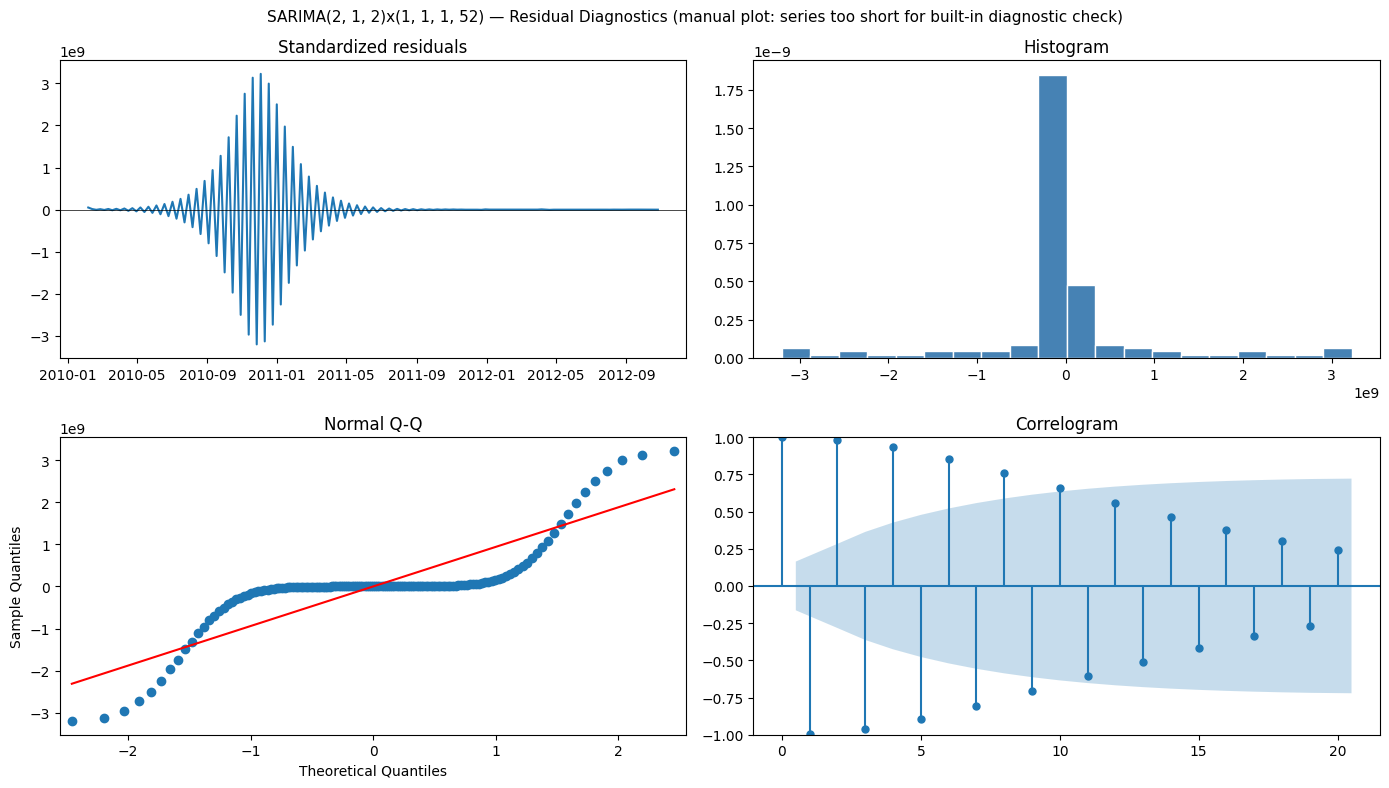

🏃 View run SARIMA_Final at: https://dagshub.com/sansi23/Walmart-Recruiting---Store-Sales-Forecasting.mlflow/#/experiments/7/runs/746f9884f03a46dea9c6a6c1bba4442a
🧪 View experiment at: https://dagshub.com/sansi23/Walmart-Recruiting---Store-Sales-Forecasting.mlflow/#/experiments/7
Diagnostics saved.


In [ ]:

diag_model = SARIMAX(
    total_ts['Total_Sales'],
    order=best_order,
    seasonal_order=best_seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False,
)
diag_fit = diag_model.fit(disp=False)

from statsmodels.graphics.gofplots import qqplot

resid = diag_fit.resid.dropna()
resid = resid[np.isfinite(resid)]

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

axes[0, 0].plot(resid.index, resid)
axes[0, 0].set_title('Standardized residuals')
axes[0, 0].axhline(0, color='k', linewidth=0.5)

axes[0, 1].hist(resid, bins=20, density=True, color='steelblue', edgecolor='white')
axes[0, 1].set_title('Histogram')

qqplot(resid, line='s', ax=axes[1, 0])
axes[1, 0].set_title('Normal Q-Q')

acf_lags = max(1, min(20, len(resid) // 2 - 1))
plot_acf(resid, lags=acf_lags, ax=axes[1, 1])
axes[1, 1].set_title('Correlogram')

plt.suptitle(f'SARIMA{best_order}x{best_seasonal_order} — Residual Diagnostics '
             f'(manual plot: series too short for built-in diagnostic check)', fontsize=11)
plt.tight_layout()
plt.savefig('sarima_diagnostics.png', dpi=100)
plt.show()

with mlflow.start_run(run_id=final_run_id):
    mlflow.log_artifact('sarima_diagnostics.png')
print("Diagnostics saved.")